<a href="https://colab.research.google.com/github/Gowtham13042007/cron_job/blob/main/VAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import tensorflow as tf
import os
import random
import numpy as np

print('Num GPUs Available',len(tf.config.experimental.list_physical_devices('GPU')))

Num GPUs Available 1


In [10]:
SEED=123456
os.environ['PYTHONHASHSEED']=str(SEED)
os.environ['TF_CUDNN_DETERMINISTIC']='1'
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [11]:
from tensorflow.keras.datasets import fashion_mnist

(x_train,y_train),(x_test,y_test)=fashion_mnist.load_data()
print(x_train.shape,y_train.shape)
print(x_test.shape,y_test.shape)
assert x_train.shape==(60000,28,28)  # total of 60000 images in which 28 cross 28 size
assert x_test.shape==(10000,28,28)
assert y_train.shape==(60000,)  # the 60000 is the category in which 0 means Tshirt 1 means shirt(y_train[0]=1)
assert y_test.shape==(10000,)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


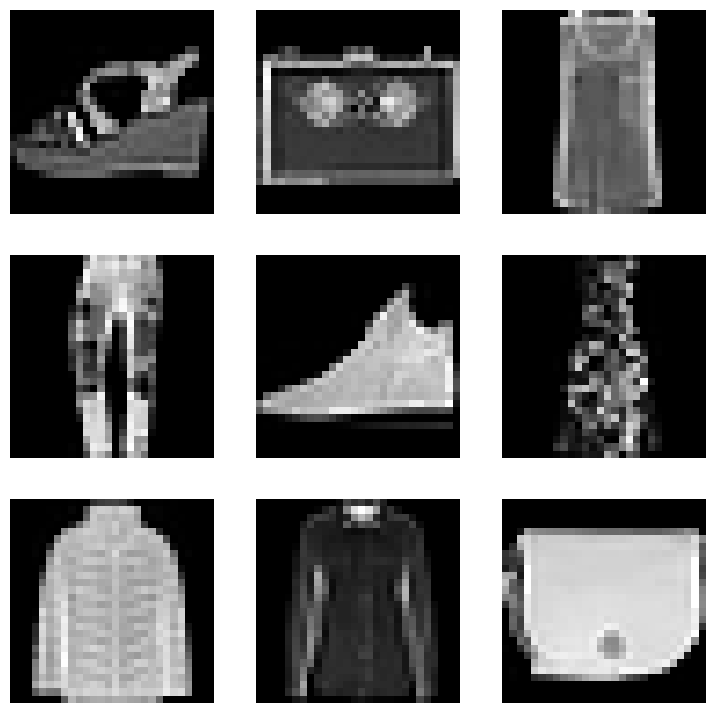

In [12]:
import numpy as np
from matplotlib import pyplot as plt

plt.figure(figsize=(9,9))
rndsamples=np.random.choice(60000,9)  # generates 9 random numbers between 0 to 59999

for i in range(9):
  plt.subplot(3,3,i+1)  # creates a subplot so that we get 9 images
  plt.imshow(x_train[rndsamples[i]],cmap='gray')
  plt.axis('off')
plt.show()

In [13]:
dataset=np.concatenate([x_train,x_test],axis=0)
print(dataset.shape)
dataset=np.expand_dims(dataset,-1).astype('float32')/255
print(dataset.shape) # as the convolutional layers expect 3 channels

(70000, 28, 28)
(70000, 28, 28, 1)


In [23]:
from tensorflow import keras
from tensorflow.keras import layers

class SamplingLayer(layers.Layer):
  def call(self,inputs):
    zMean,zLogVar=inputs
    batch=tf.shape(zMean)[0]
    dim=tf.shape(zMean)[1]
    epsilon=tf.keras.backend.random_normal(shape=(batch,dim))
    return zMean+tf.exp(0.5*zLogVar)*epsilon

In [15]:
def buildEncoder(latentDim,encoderInputs):
  l1=keras.models.Sequential([
      layers.Conv2D(128,3,activation='relu',strides=2,padding='same'),  #128-number of layers,3-kernel size(3 cross 3), strides =2 means (36 cross 36 is taken down to 18 cross 18)
      layers.Conv2D(64,3,activation='relu',strides=2,padding='same'),
      layers.Flatten(),
      layers.Dense(256,activation='relu'),
  ])

  x=l1(encoderInputs)
  zMean=layers.Dense(latentDim,name='z_mean')(x)
  zLogVar=layers.Dense(latentDim,name='z_log_var')(x)
  z=SamplingLayer()([zMean,zLogVar])
  return keras.Model(encoderInputs,[zMean,zLogVar,z],name='encoder')

encoderInputs=keras.Input(shape=(28,28,1))
encoder=buildEncoder(latentDim=2,encoderInputs=encoderInputs)
encoder.summary()


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 256)       │    878,144 │ input_layer[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        514 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        514 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_layer      │ (None, 2)         │          0 │ z_mean[0][0],     │
│ (SamplingLayer)     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 879,172 (3.35 MB)

 Trainable params: 879,172 (3.35 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
def buildDecoder(latentInputs):
  l1=keras.models.Sequential([
      layers.Dense(7*7*64,activation='relu'),
      layers.Reshape((7,7,64)),
      layers.Conv2DTranspose(128,3,activation='relu',strides=2,padding='same'),
      layers.Conv2DTranspose(128,3,activation='relu',strides=2,padding='same'),
      layers.Conv2D(1,3,activation='sigmoid',padding='same')
  ])

  x=l1(latentInputs)
  return keras.Model(latentInputs,x,name='decoder')

latentInputs=keras.Input(shape=(2,))
decoder=buildDecoder(latentInputs)
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 28, 28, 1)      │       232,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 232,001 (906.25 KB)

 Trainable params: 232,001 (906.25 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
def reconstructionLoss(inputs,reconstructions):
  return tf.reduce_mean(tf.reduce_sum(
      keras.losses.binary_crossentropy(inputs,reconstructions),
      axis=(1,2)
  ))

In [19]:
def klDivergenceLoss(zMean,zLogVar):
  return tf.reduce_mean(
      tf.reduce_sum(
          -0.5*(1+zLogVar-tf.square(zMean)-tf.exp(zLogVar)),
          axis=1
      )
  )

In [20]:
def calcTotalloss(data,reconstructed,zmean,zLogVar):
  loss1=reconstructionLoss(data,reconstructed)
  loss2=klDivergenceLoss(zmean,zLogVar)
  klweight=3.0
  return loss1,loss2,loss1+klweight*loss2

In [25]:
class VAE(keras.Model):
  def __init__(self,encoder,decoder,**kwargs):
    super(VAE,self).__init__(**kwargs)
    self.encoder=encoder
    self.decoder=decoder
    self.totalLossTracker=keras.metrics.Mean(name='total_loss')
    self.reconstructionLossTracker=keras.metrics.Mean(name='reconstruction_loss')
    self.klDivergenceLossTracker=keras.metrics.Mean(name='kl_divergence_loss')

  @property  # without property we use s.name() but with property s.name
  def metrics(self):
    return [
        self.totalLossTracker,
        self.reconstructionLossTracker,
        self.klDivergenceLossTracker
    ]

  def train_step(self,data):
      with tf.GradientTape() as tape:
        zMean,zLogVar,z=self.encoder(data)
        reconstructed=self.decoder(z)
        ceLoss,kLoss,totalLoss=calcTotalloss(data,reconstructed,zMean,zLogVar)
      grads=tape.gradient(totalLoss,self.trainable_weights)
      self.optimizer.apply_gradients(zip(grads,self.trainable_weights))
      self.totalLossTracker.update_state(totalLoss)
      self.reconstructionLossTracker.update_state(ceLoss)
      self.klDivergenceLossTracker.update_state(kLoss)

      return {
          'total_loss':self.totalLossTracker.result(),
          'reconstruction_loss':self.reconstructionLossTracker.result(),
          'kl_divergence_loss':self.klDivergenceLossTracker.result()
      }


In [33]:
vae=VAE(encoder,decoder)
vae.compile(optimizer=keras.optimizers.Adam())
history=vae.fit(dataset,epochs=32,batch_size=128)

Epoch 1/32
547/547 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - kl_divergence_loss: 5.4064 - reconstruction_loss: 247.7728 - total_loss: 263.9922
Epoch 2/32
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - kl_divergence_loss: 5.4065 - reconstruction_loss: 247.6796 - total_loss: 263.8994
Epoch 3/32
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - kl_divergence_loss: 5.4054 - reconstruction_loss: 247.6693 - total_loss: 263.8853
Epoch 4/32
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - kl_divergence_loss: 5.4286 - reconstruction_loss: 247.6186 - total_loss: 263.9046
Epoch 5/32
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - kl_divergence_loss: 5.4264 - reconstruction_loss: 247.5193 - total_loss: 263.7987
Epoch 6/32
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - kl_divergence_loss: 5.4222 - reconstruction_loss: 247.5577 - total_loss: 263.8243
Epoch 7/32
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - kl_divergence_loss: 5.4204 - reconstruction_loss: 247.4923 - total_loss: 263.7535
Epoch 8/32
547/547 ━━━━━━━━━━━━━━━

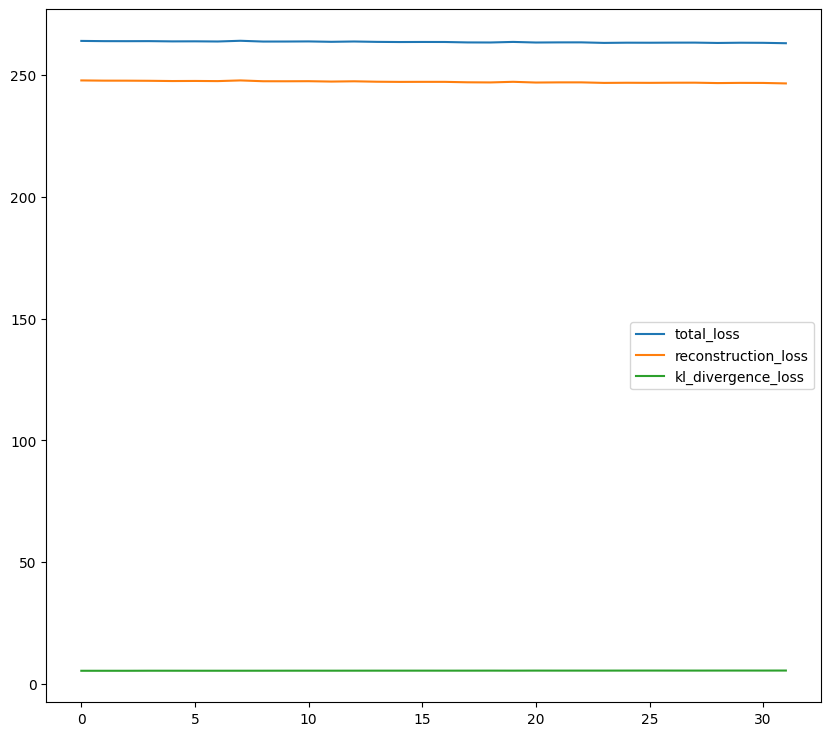

In [34]:

plt.figure(figsize=(10,9))
plt.plot(history.history.get('total_loss'),label='total_loss')
plt.plot(history.history.get('reconstruction_loss'),label='reconstruction_loss')
plt.plot(history.history.get('kl_divergence_loss'),label='kl_divergence_loss')
plt.legend()

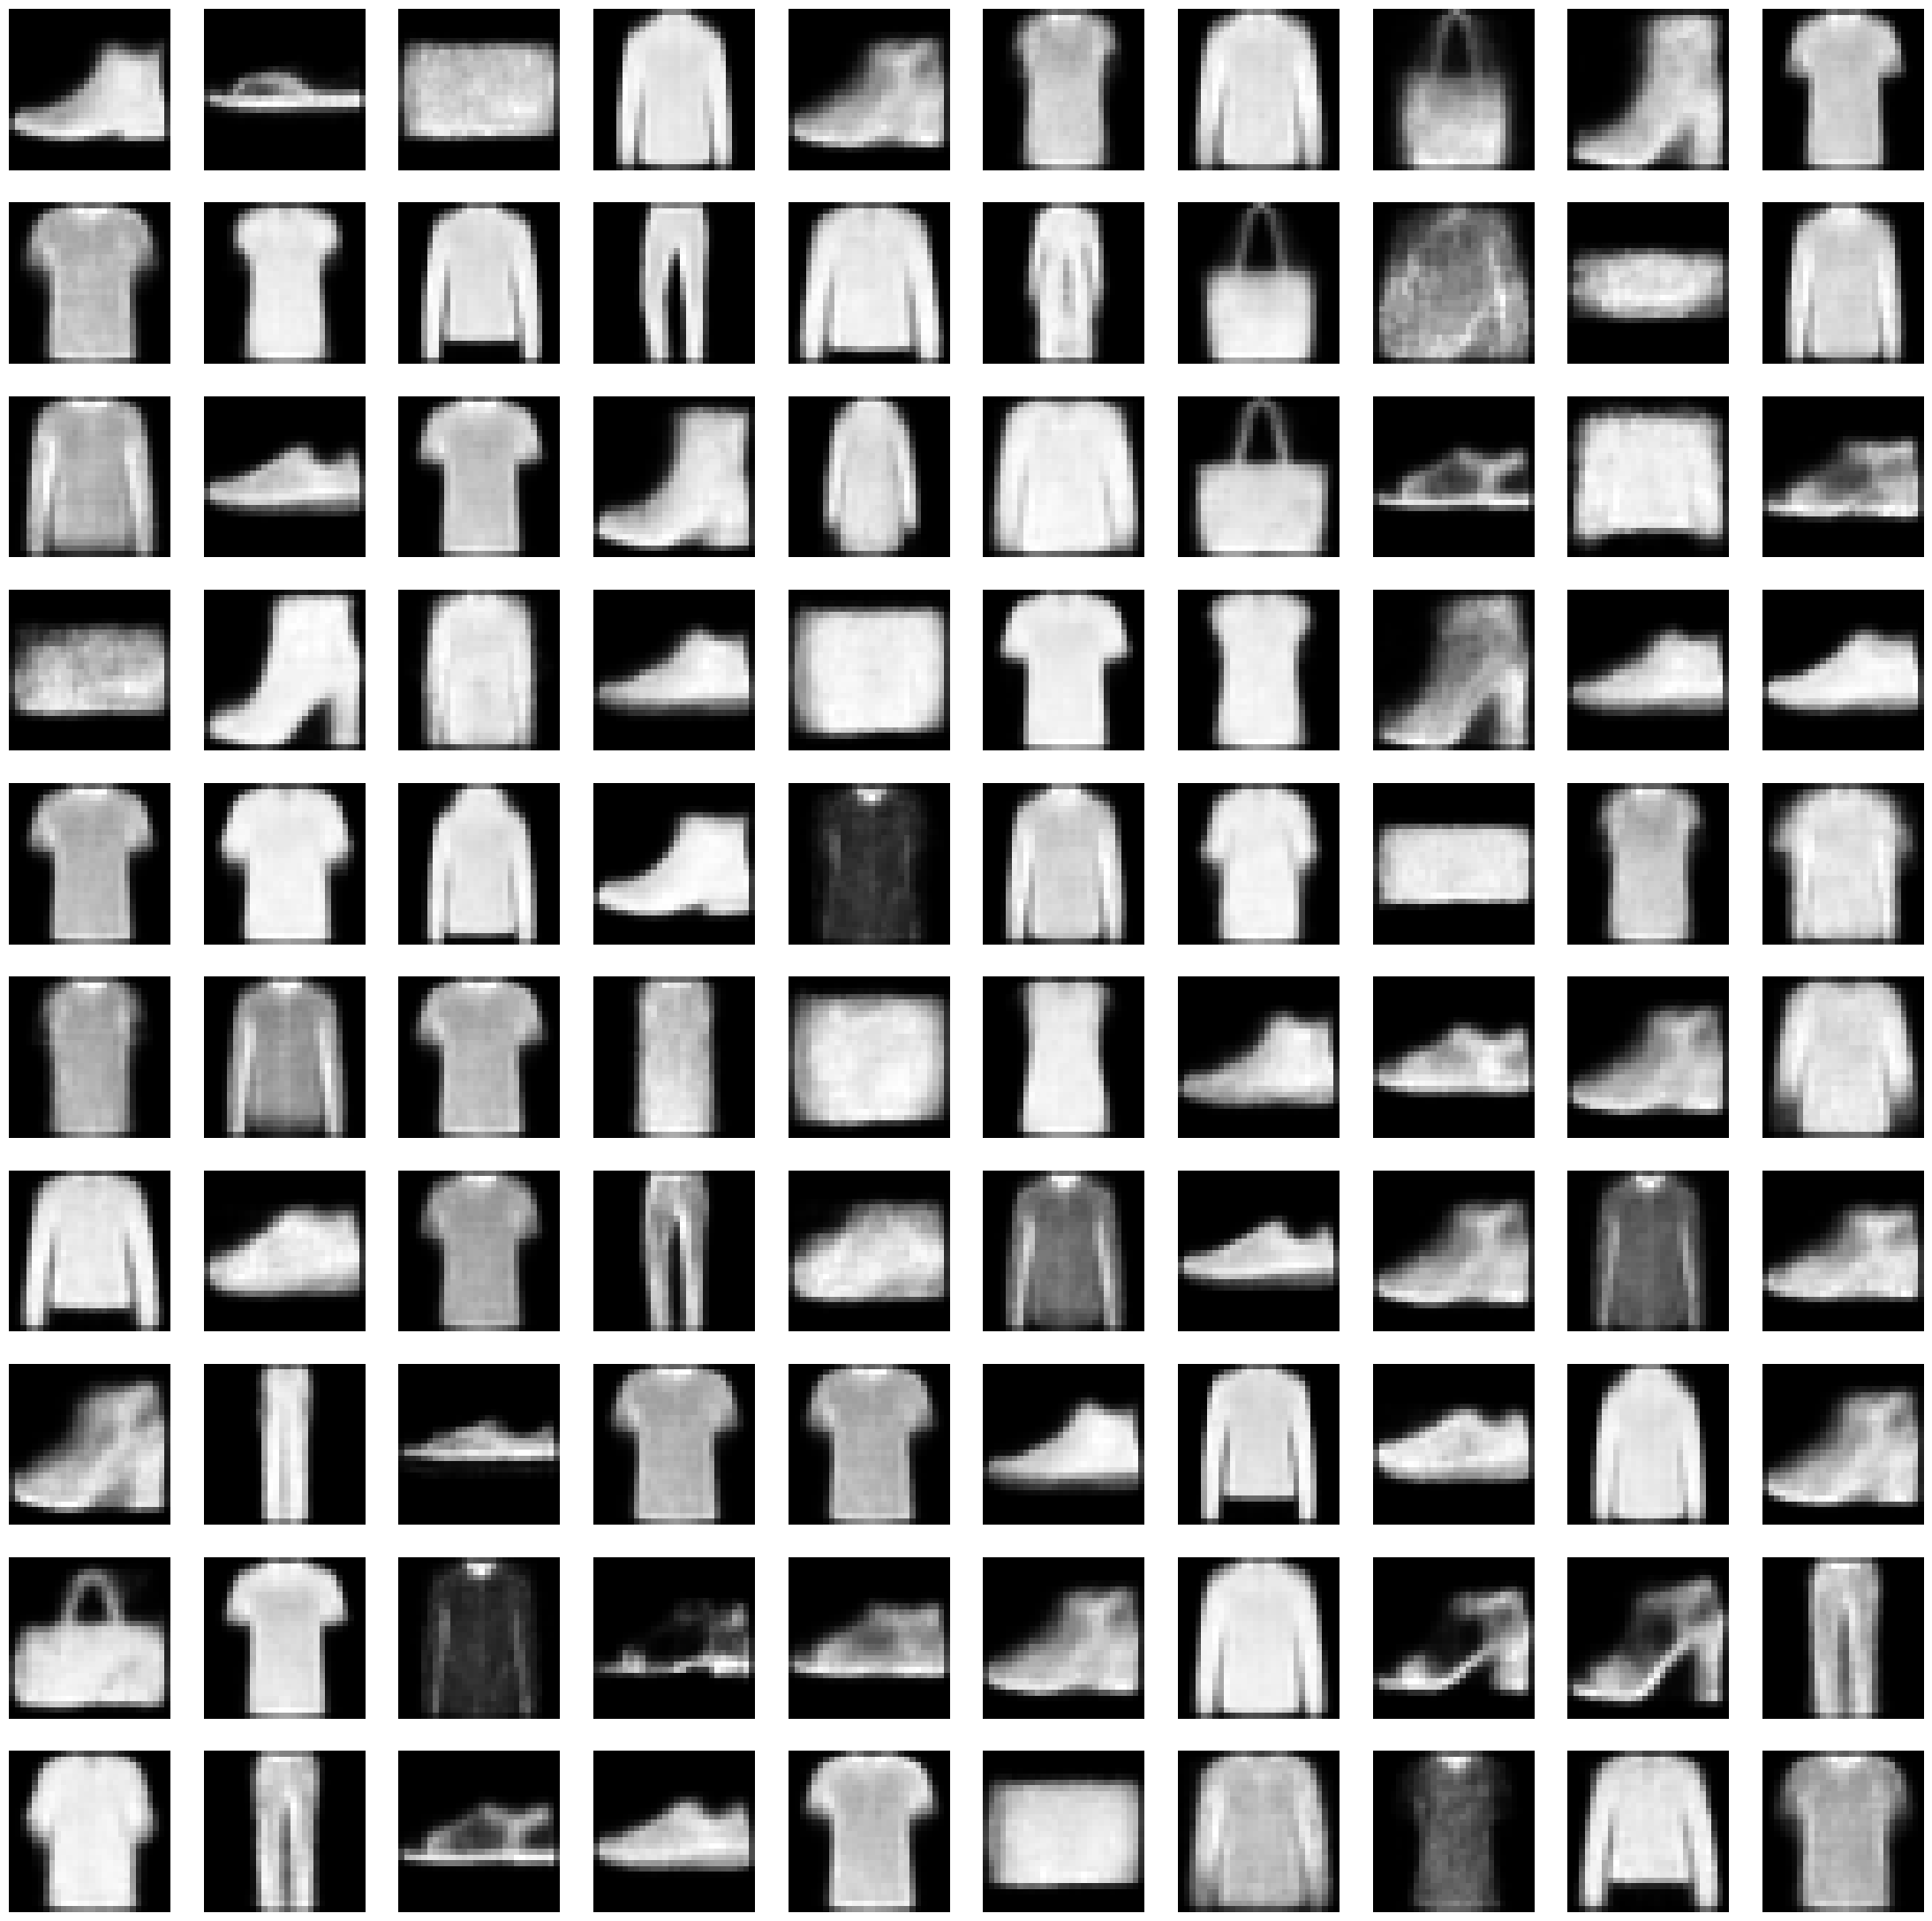

In [37]:
synth=vae.decoder(tf.random.normal(shape=(100,2)))

plt.figure(figsize=(28,28))

for i in range(100):
  plt.subplot(10,10,i+1)
  plt.imshow(tf.reshape(synth[i],(28,28)),cmap='gray')
  plt.axis('off')
plt.show()

(1, 28, 28, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
tf.Tensor([[0.1733461  0.63105047]], shape=(1, 2), dtype=float32)


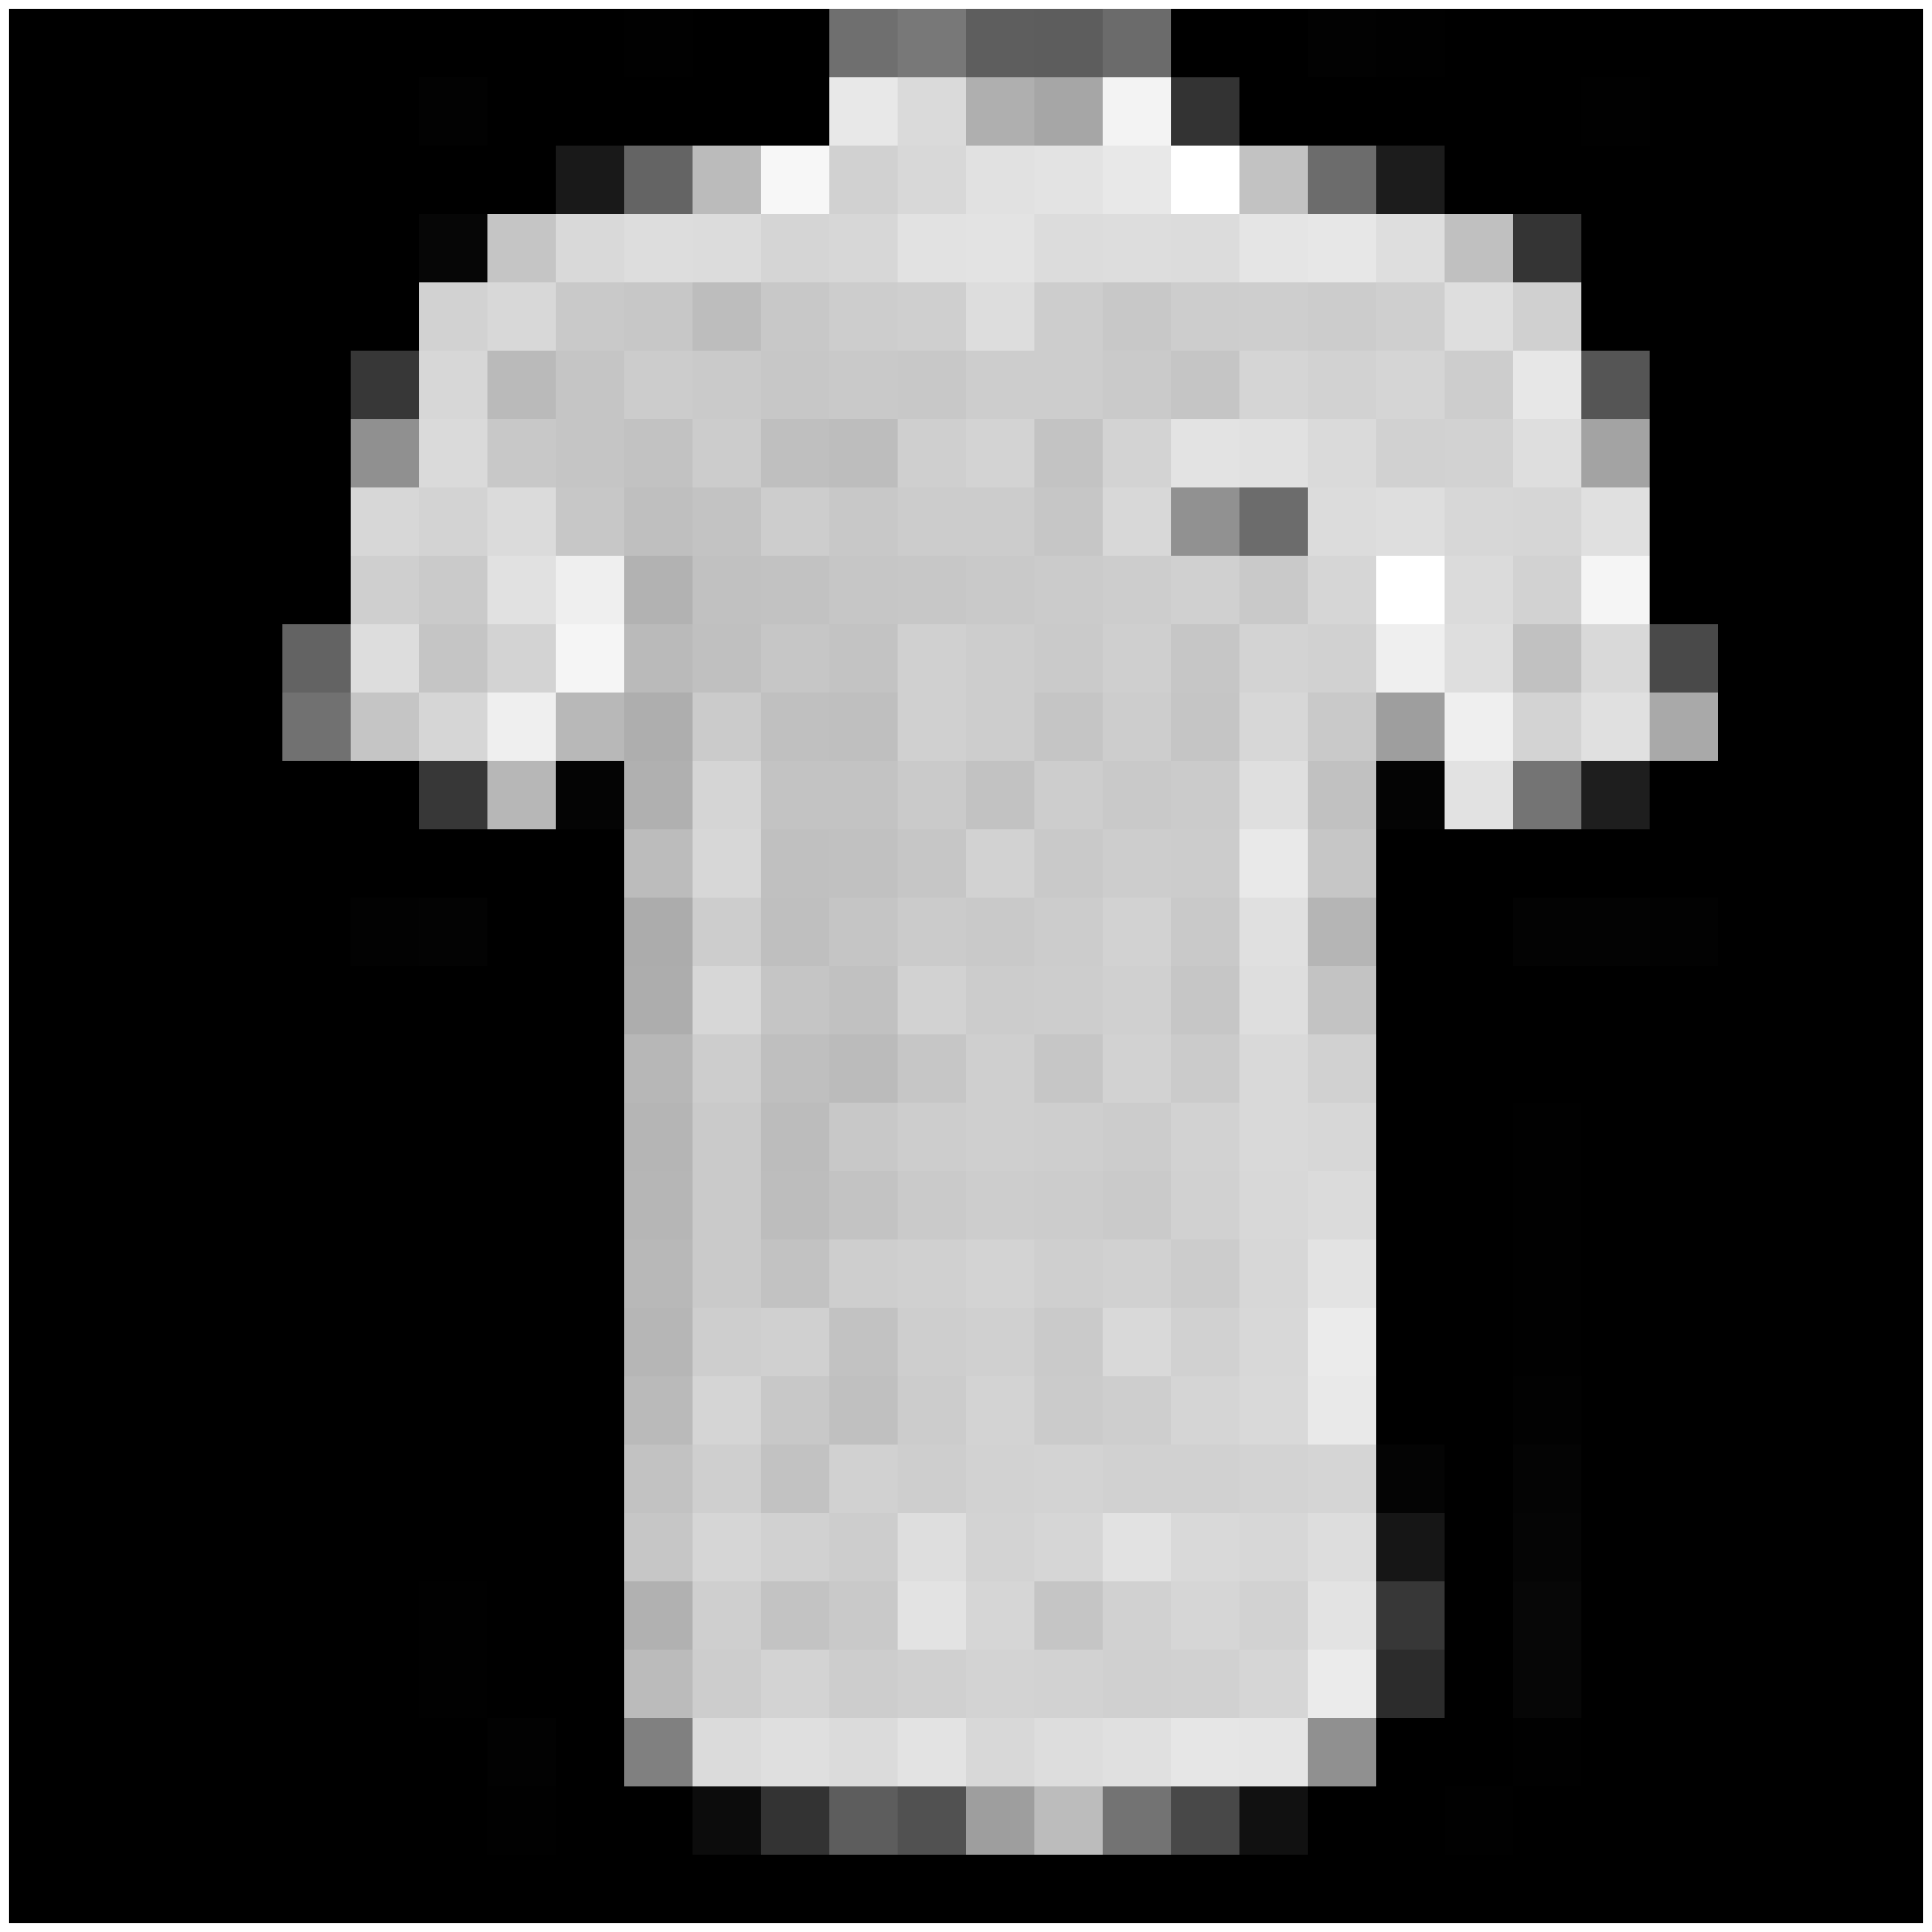

In [44]:
idx=1200

batch=np.expand_dims(x_train[idx],axis=0)   # (1,28,28)

batchOfimages=np.expand_dims(batch,axis=-1).astype('float32')/255
# shape becomes (1,28,28,1)

print(batchOfimages.shape)

zMean,zLogVar,z=vae.encoder(batchOfimages)

synth=vae.decoder.predict(z)

print(z)

plt.figure(figsize=(28,28))
plt.imshow(tf.reshape(batchOfimages[0],(28,28)),cmap='gray')
plt.axis('off')
plt.show()

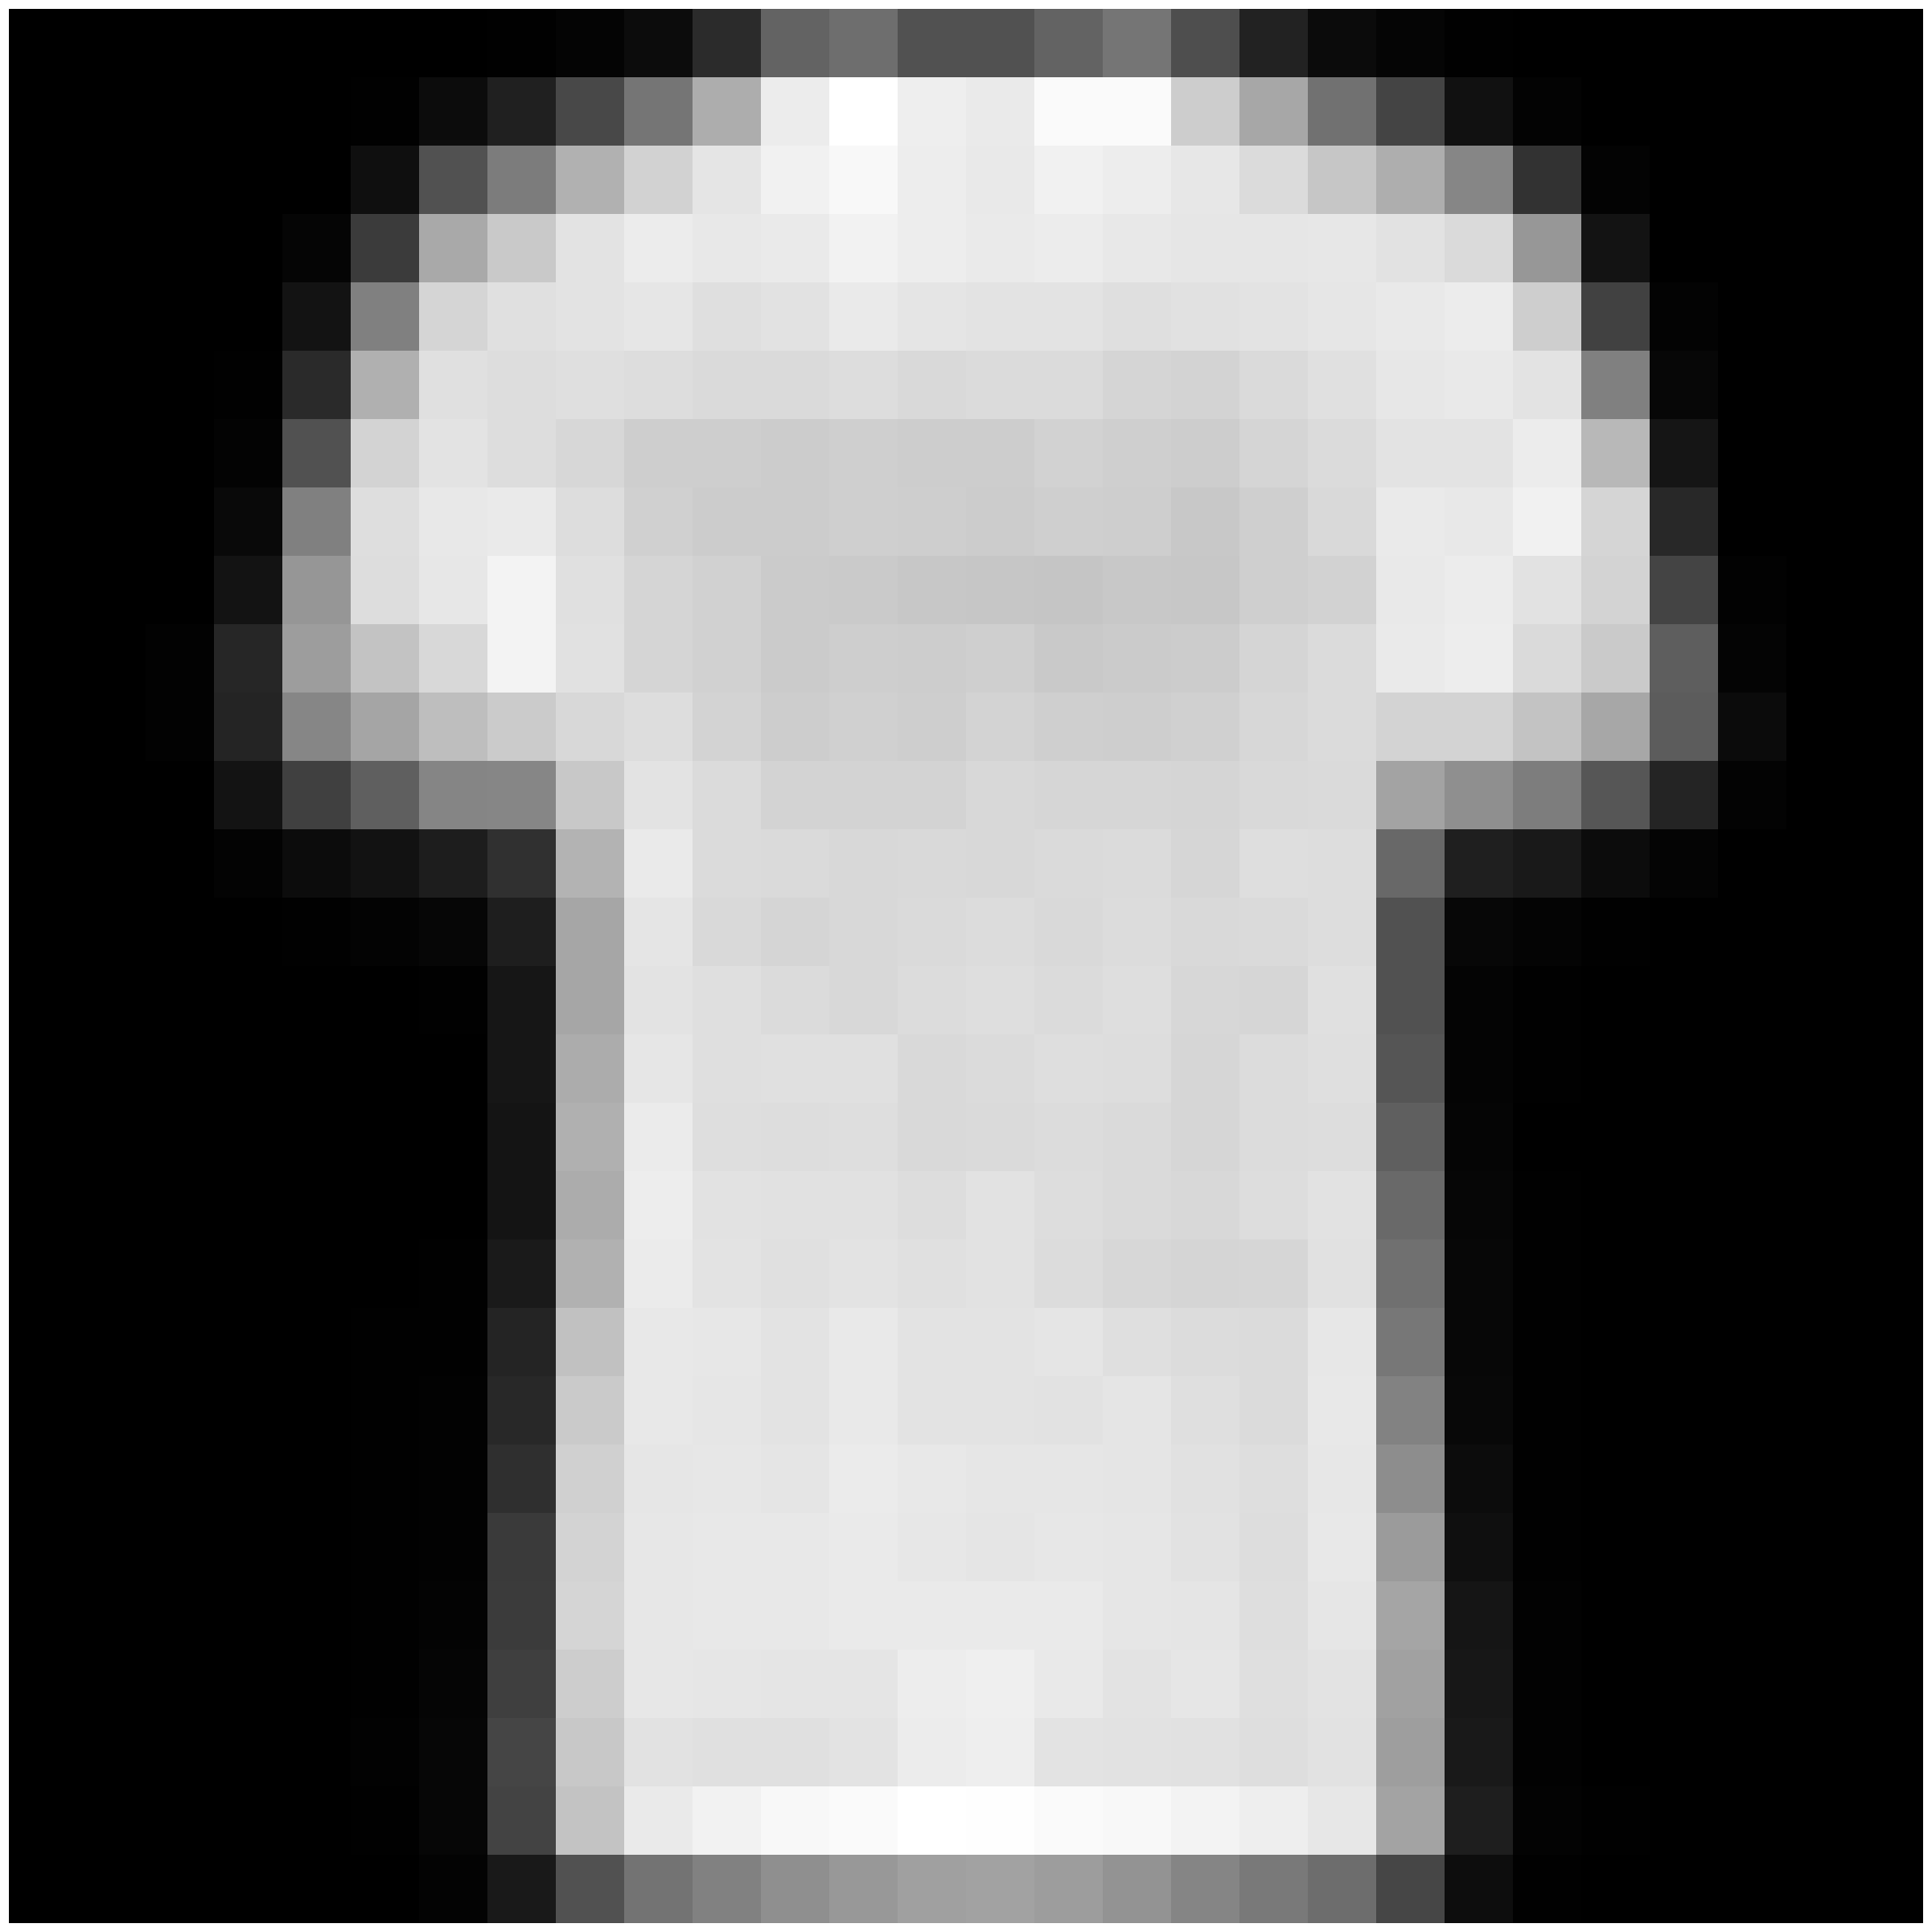

In [46]:
plt.figure(figsize=(28,28))
plt.imshow(tf.reshape(synth[0],(28,28)),cmap='gray')
plt.axis('off')
plt.show()